<a href="https://colab.research.google.com/github/shuc9663-source/GEOG5990_Assignment2_201929754/blob/main/GEOG5990M_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOG5990M Final Assignment

(The cover sheet has been adapted from the word doc. to support use with .ipynb files - please complete all the requested info.)
###  COURSEWORK COVERSHEET
- Student ID number: 201929754
- Module code: GEOG5990M
- Module title: Programming for Geographical Information Analysis: Core Skills
- Assignment title: Spatial data science report
- Marker: Francesca Pontin
- Declared word count:

#### Use of Generative Artificial Intelligence (Gen AI) in this assessment – delete one statement as appropriate
- I have made no use of Gen A
- I have used Gen AI only for the specific purposes outlined in my acknowledgements


By submitting the work in this notebook you confirm your compliance with the University’s definition of Academic Integrity as: “a commitment to good study practices and shared values which ensures that my work is a true expression of my own understanding and ideas, giving credit to others where their work contributes to mine”. Double-check that your referencing and use of quotations is consistent with this commitment.

You also confirm that your declared word count accurately reflects the number of words in your submission, excluding the overall title, Gen AI use acknowledgement, bibliography/reference list, text/numbers in tables and figures (although table and figure captions are included in the word count).

In [32]:
# Read in required packages

# import any further required packages
!pip install git+https://github.com/pmdscully/geo_northarrow.git
# Import pandas for reading, cleaning and analysing tabular datasets
import pandas as pd
# Import geopandas for reading, processing and mapping spatial boundary data
import geopandas as gpd
# Import numpy for numerical operations
import numpy as np
# Import matplotlib.pyplot for creating charts and maps within the notebook
import matplotlib.pyplot as plt
# Import seaborn for creating clearer statistical visualisations
import seaborn as sns
# This package is used to add a north arrow to maps
from geo_northarrow import add_north_arrow
# Import warnings so that non-critical warning messages can be controlled during the analysis
import warnings
# Hide non-critical warnings to keep the notebook output cleaner
warnings.filterwarnings("ignore")

  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-ompcz5s_
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-ompcz5s_
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for geo_northarrow: filename=geo_northarrow-0.2.0a0-py3-none-any.whl size=14940 sha256=492d804708660e58b3d3f9aa6ab70df4294de4611ea66457c2d4548883413f2e
  Stored in directory: /tmp/pip-ephem-wheel-cache-zpsrynwt/wheels/d7/28/6c/cb006605c19bc4f58db715626f7113a6858d8c002e8c52fa80
Successfully built geo_northarrow


In [3]:
# Read in database

# Clone the GitHub repository into the Colab environment
!git clone https://github.com/shuc9663-source/GEOG5990_Assignment2_201929754.git
# Change the working directory to the cloned GitHub repository
%cd GEOG5990_Assignment2_201929754
# Read the MSOA boundary file from the local raw data folder
msoa_boundaries = gpd.read_file("data/msoa_boundaries.shp")
# Read the Census 2011 MSOA-level data from the second worksheet of the Excel file
census = pd.read_excel("data/London-MSOA-retailer-data.xlsx", sheet_name="Project_1_Data")
# Read the epraccur GP practice reference file from the local raw data folder.The data is missing column names
gp_practices = pd.read_csv("data/epraccur.csv", header=None)
# Create generic column names for all columns in the epraccur dataset
gp_practices.columns = [f"col_{i}" for i in range(gp_practices.shape[1])]
# Rename the key columns required for this analysis based on the observed epraccur structure
gp_practices = gp_practices.rename(columns={
    "col_0": "practice_code",
    "col_1": "practice_name",
    "col_4": "address_line_1",
    "col_5": "address_line_2",
    "col_7": "town",
    "col_9": "postcode",
    "col_10": "open_date",
    "col_11": "close_date",
    "col_12": "status",
})
# Keep only the columns needed for the healthcare accessibility analysis.
gp_practices = gp_practices[[
    "practice_code",
    "practice_name",
    "address_line_1",
    "address_line_2",
    "town",
    "postcode",
    "open_date",
    "close_date",
    "status"
]]
# Read the Patients Registered at a GP Practice dataset from the local raw data folder
gp_patients = pd.read_csv("data/gp-reg-pat-prac-all.csv")
# Read the London-filtered ONS Postcode Directory from the local raw data folder
onspd_london = pd.read_csv("data/ONSPD_2025_5_London.csv")

Cloning into 'GEOG5990_Assignment2_201929754'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 80 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 2.03 MiB | 7.17 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/GEOG5990_Assignment2_201929754


In [5]:
# Inspect the datasets

# Display the first five rows of the MSOA boundary dataset
display(msoa_boundaries.head())
# Display the first five rows of the Census dataset
display(census.head())
# Display the first five rows of the GP practice reference dataset
display(gp_practices.head())
# Display the first five rows of the registered patients dataset
display(gp_patients.head())
# Display the first five rows of the London postcode lookup dataset
display(onspd_london.head())
# Check the coordinate reference system of the MSOA boundary dataset
print("MSOA boundary CRS:", msoa_boundaries.crs)

,objectid,msoa11cd,msoa11nm,msoa11nmw,st_areasha,st_lengths,geometry
0,1.0,E02000001,City of London 001,City of London 001,2.983633e+06,8017.914674,"POLYGON ((532946.063 181894.828, 533410.685 18..."
1,2.0,E02000002,Barking and Dagenham 001,Barking and Dagenham 001,2.091907e+06,7086.028359,"POLYGON ((547804.358 188626.83, 547514.561 189..."
2,3.0,E02000003,Barking and Dagenham 002,Barking and Dagenham 002,2.122216e+06,7405.118745,"POLYGON ((548954.497 189063.203, 549099.632 18..."
3,4.0,E02000004,Barking and Dagenham 003,Barking and Dagenham 003,2.569470e+06,7148.814421,"POLYGON ((551943.81 186027.672, 551670.809 185..."
4,5.0,E02000005,Barking and Dagenham 004,Barking and Dagenham 004,1.111109e+06,5491.227647,"POLYGON ((549026.795 186159.797, 548046.424 18..."


,MSOA,Total_Population,Total_Households,Total_Population_16_and_over,Total_Population_16_to_74,Total_Employment_16_to_74,Total_Population_in_Households_16_and_over,Age_0_to_4,Age_5_to_9,Age_10_to_14,...,Associate_professional_and_technical_occupations,Administrative_and_secretarial_occupations,Skilled_trades_occupations,Caring_leisure_and_other_service_occupations,Sales_and_customer_service_occupations,Process_plant_and_machine_operatives,Elementary_occupations,Median_House_Price_201415,Average_Annual_Income_201516,Number_Births_201617
0,E02000001,7375,4385,6755,6307,4747,6595,236,182,169,...,1097,335,114,128,109,52,173,816350,79700,68
1,E02000002,6775,2713,5024,4360,2470,4973,628,586,446,...,229,323,310,302,261,218,329,240000,38600,136
2,E02000003,10045,3834,7798,7149,4520,7786,833,673,620,...,517,714,503,438,408,346,508,250000,46400,184
3,E02000004,6182,2318,4986,4438,2847,4741,365,335,408,...,345,470,385,270,241,256,280,252500,45300,98
4,E02000005,8562,3183,6362,5933,3582,6362,796,631,635,...,286,516,495,434,342,361,489,240000,41000,179


,practice_code,practice_name,address_line_1,address_line_2,town,postcode,open_date,close_date,status
0,A81001,THE DENSHAM SURGERY,HEALTH CENTRE,LAWSON STREET,STOCKTON-ON-TEES,TS18 1HU,19740401,NaN,ACTIVE
1,A81002,QUEENS PARK MEDICAL CENTRE,FARRER STREET,NaN,STOCKTON ON TEES,TS18 2AW,19740401,NaN,ACTIVE
2,A81003,VICTORIA MEDICAL PRACTICE,HEALTH CENTRE,VICTORIA ROAD,HARTLEPOOL,TS26 8DB,19740401,20171031.0,INACTIVE
3,A81004,ACKLAM MEDICAL CENTRE,TRIMDON AVENUE,ACKLAM,MIDDLESBROUGH,TS5 8SB,19740401,NaN,ACTIVE
4,A81005,SPRINGWOOD SURGERY,RECTORY LANE,NaN,GUISBOROUGH,TS14 7DJ,19740401,NaN,ACTIVE


,PUBLICATION,EXTRACT_DATE,TYPE,SUB_ICB_LOCATION_CODE,ONS_SUB_ICB_LOCATION_CODE,CODE,POSTCODE,SEX,AGE,NUMBER_OF_PATIENTS
0,GP_PRAC_PAT_LIST,2026-04-01,GP,16C,E38000247,A81001,TS18 1HU,ALL,ALL,3747
1,GP_PRAC_PAT_LIST,2026-04-01,GP,16C,E38000247,A81002,TS18 2AW,ALL,ALL,18654
2,GP_PRAC_PAT_LIST,2026-04-01,GP,16C,E38000247,A81004,TS5 8SB,ALL,ALL,11437
3,GP_PRAC_PAT_LIST,2026-04-01,GP,16C,E38000247,A81005,TS14 7DJ,ALL,ALL,7571
4,GP_PRAC_PAT_LIST,2026-04-01,GP,16C,E38000247,A81006,TS18 2AT,ALL,ALL,14584


,pcds,oslaua,lat,long,lsoa21,msoa21
0,BR1 1AA,E09000006,51.401545,0.015440,E01034386,E02000144
1,BR1 1AB,E09000006,51.406333,0.015234,E01000676,E02000134
2,BR1 1AD,E09000006,51.400057,0.016741,E01034386,E02000144
3,BR1 1AE,E09000006,51.404543,0.014221,E01000677,E02000144
4,BR1 1AF,E09000006,51.401391,0.014973,E01034386,E02000144


MSOA boundary CRS: PROJCS["Transverse_Mercator",GEOGCS["GCS_Airy 1830",DATUM["unknown",SPHEROID["airy",6377563.396,299.3249646]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [6]:
# clean and standardise key identifiers

# Define a function to clean postcode strings into a consistent format
def clean_postcode(postcode):
    # Convert the postcode to a string, remove leading and trailing spaces, convert to uppercase, and remove internal spaces
    return str(postcode).strip().upper().replace(" ", "")
# Create a cleaned postcode field in the GP practice reference dataset
gp_practices["postcode_clean"] = gp_practices["postcode"].apply(clean_postcode)
# Create a cleaned postcode field in the London postcode lookup dataset
onspd_london["postcode_clean"] = onspd_london["pcds"].apply(clean_postcode)
# Create a standard GP practice code field in the GP practice reference dataset
gp_practices["practice_code"] = gp_practices["practice_code"].astype(str).str.strip()
# Create a standard GP practice code field in the registered patients dataset
gp_patients["practice_code"] = gp_patients["CODE"].astype(str).str.strip()
# Create a standard MSOA code field in the London postcode lookup dataset
onspd_london["msoa_code"] = onspd_london["msoa21"].astype(str).str.strip()
# Create a standard latitude field in the London postcode lookup dataset
onspd_london["latitude"] = pd.to_numeric(onspd_london["lat"], errors="coerce")
# Create a standard longitude field in the London postcode lookup dataset
onspd_london["longitude"] = pd.to_numeric(onspd_london["long"], errors="coerce")

# Create a standard MSOA code field in the MSOA boundary dataset
msoa_boundaries["msoa_code"] = msoa_boundaries["msoa11cd"].astype(str).str.strip()
# Create a standard MSOA code field in the Census dataset
census["msoa_code"] = census["MSOA"].astype(str).str.strip()

# Display the first five cleaned postcodes and practice codes from the GP practice reference dataset
display(gp_practices[["practice_code", "postcode_clean"]].head())
# Display the first five cleaned postcodes and MSOA codes from the postcode lookup dataset
display(onspd_london[["postcode_clean", "msoa_code", "latitude", "longitude"]].head())
# Display the first five standardised MSOA codes from the MSOA boundary dataset
display(msoa_boundaries[["msoa_code"]].head())
# Display the first five standardised MSOA codes from the Census dataset
display(census[["msoa_code"]].head())

# Count missing cleaned postcodes in the GP practice reference dataset
print("Missing GP practice postcodes:", gp_practices["postcode_clean"].isna().sum())
# Count missing cleaned postcodes in the postcode lookup dataset
print("Missing ONSPD postcodes:", onspd_london["postcode_clean"].isna().sum())
# Count missing MSOA codes in the postcode lookup dataset
print("Missing ONSPD MSOA codes:", onspd_london["msoa_code"].isna().sum())
# Count missing latitude values in the postcode lookup dataset
print("Missing ONSPD latitude values:", onspd_london["latitude"].isna().sum())
# Count missing longitude values in the postcode lookup dataset
print("Missing ONSPD longitude values:", onspd_london["longitude"].isna().sum())
# Count missing MSOA codes in the MSOA boundary dataset
print("Missing boundary MSOA codes:", msoa_boundaries["msoa_code"].isna().sum())
# Count missing MSOA codes in the Census dataset
print("Missing Census MSOA codes:", census["msoa_code"].isna().sum())

,practice_code,postcode_clean
0,A81001,TS181HU
1,A81002,TS182AW
2,A81003,TS268DB
3,A81004,TS58SB
4,A81005,TS147DJ


,postcode_clean,msoa_code,latitude,longitude
0,BR11AA,E02000144,51.401545,0.015440
1,BR11AB,E02000134,51.406333,0.015234
2,BR11AD,E02000144,51.400057,0.016741
3,BR11AE,E02000144,51.404543,0.014221
4,BR11AF,E02000144,51.401391,0.014973


,msoa_code
0,E02000001
1,E02000002
2,E02000003
3,E02000004
4,E02000005


,msoa_code
0,E02000001
1,E02000002
2,E02000003
3,E02000004
4,E02000005


Missing GP practice postcodes: 0
Missing ONSPD postcodes: 0
Missing ONSPD MSOA codes: 0
Missing ONSPD latitude values: 0
Missing ONSPD longitude values: 0
Missing boundary MSOA codes: 0
Missing Census MSOA codes: 0


In [7]:
# Link GP practices to MSOAs using postcode

# Select only the postcode, MSOA and coordinate fields needed from the London postcode lookup
onspd_lookup = onspd_london[["postcode_clean", "msoa_code", "latitude", "longitude"]].copy()
# Join the GP practice dataset to the postcode lookup using the cleaned postcode field
gp_msoa = gp_practices.merge(onspd_lookup, on="postcode_clean", how="left")
# Display the number of GP practices before the postcode lookup join
print("Number of GP practices before postcode lookup:", len(gp_practices))
# Display the number of GP practices after the postcode lookup join
print("Number of GP practices after postcode lookup:", len(gp_msoa))
# Display the first five rows of the joined GP practice dataset
display(gp_msoa.head())


# Keep only GP practices that were successfully matched to a London MSOA
gp_london = gp_msoa.dropna(subset=["msoa_code", "latitude", "longitude"]).copy()
# Count the number of GP practices after filtering to London
print("Number of active GP practices matched to London MSOAs:", len(gp_london))
# Display the first five London GP practices to check the matched records
display(gp_london[["practice_code", "practice_name", "postcode", "postcode_clean", "msoa_code", "latitude", "longitude"]].head())

Number of GP practices before postcode lookup: 15493
Number of GP practices after postcode lookup: 15493


,practice_code,practice_name,address_line_1,address_line_2,town,postcode,open_date,close_date,status,postcode_clean,msoa_code,latitude,longitude
0,A81001,THE DENSHAM SURGERY,HEALTH CENTRE,LAWSON STREET,STOCKTON-ON-TEES,TS18 1HU,19740401,NaN,ACTIVE,TS181HU,NaN,NaN,NaN
1,A81002,QUEENS PARK MEDICAL CENTRE,FARRER STREET,NaN,STOCKTON ON TEES,TS18 2AW,19740401,NaN,ACTIVE,TS182AW,NaN,NaN,NaN
2,A81003,VICTORIA MEDICAL PRACTICE,HEALTH CENTRE,VICTORIA ROAD,HARTLEPOOL,TS26 8DB,19740401,20171031.0,INACTIVE,TS268DB,NaN,NaN,NaN
3,A81004,ACKLAM MEDICAL CENTRE,TRIMDON AVENUE,ACKLAM,MIDDLESBROUGH,TS5 8SB,19740401,NaN,ACTIVE,TS58SB,NaN,NaN,NaN
4,A81005,SPRINGWOOD SURGERY,RECTORY LANE,NaN,GUISBOROUGH,TS14 7DJ,19740401,NaN,ACTIVE,TS147DJ,NaN,NaN,NaN


Number of active GP practices matched to London MSOAs: 732


,practice_code,practice_name,postcode,postcode_clean,msoa_code,latitude,longitude
470,A91039,NORTHOLT MEDICAL CENTRE,HA4 6NG,HA46NG,E02006796,51.558047,-0.409398
665,A99896,MILE END HOSPITAL - BCSS INPATIENT UNIT,E1 4DG,E14DG,E02000873,51.525049,-0.042179
694,A99925,ST MARKS BOWEL CANCER SCREENING CENTRE,HA1 3UJ,HA13UJ,E02000100,51.575409,-0.322015
748,A99979,NORTH EAST LONDON BOWEL CANCER SCREENING CENTRE,E9 6SR,E96SR,E02000363,51.550635,-0.046072
2508,E83012,THE OLD COURT HOUSE SURGERY,EN5 4BB,EN54BB,E02000024,51.652902,-0.201566


In [8]:
# Create GP point layer and calculate distance to nearest GP practice


# Convert the longitude field in the London GP dataset to numeric format
gp_london["longitude"] = pd.to_numeric(gp_london["longitude"], errors="coerce")
# Convert the latitude field in the London GP dataset to numeric format
gp_london["latitude"] = pd.to_numeric(gp_london["latitude"], errors="coerce")
# Remove GP practices with missing longitude or latitude values after numeric conversion
gp_london = gp_london.dropna(subset=["longitude", "latitude"]).copy()
# Create a GeoDataFrame of London GP practices using longitude and latitude as point coordinates.I used ChatGPT-5.5 to inquire about the method of creating a point layer using latitude and longitude.
gp_points = gpd.GeoDataFrame(
    gp_london,
    geometry=gpd.points_from_xy(gp_london["longitude"], gp_london["latitude"]),
    crs="EPSG:4326"
)
# Display the number of London GP practice points created
print("Number of London GP practice points:", len(gp_points))
# Display the coordinate reference system of the GP point layer
print("GP point CRS:", gp_points.crs)
# Display the first five GP practice point records
display(gp_points[["practice_code", "practice_name", "postcode", "msoa_code", "geometry"]].head())


# Reproject the GP point layer to British National Grid
gp_points_bng = gp_points.to_crs(epsg=27700)
# Reproject the MSOA boundary layer to British National Grid
msoa_boundaries_bng = msoa_boundaries.to_crs(epsg=27700)
# Display the coordinate reference system
print("Projected GP point CRS:", gp_points_bng.crs)
print("Projected MSOA boundary CRS:", msoa_boundaries_bng.crs)


# Create a copy of the projected MSOA boundary layer for centroid calculation
msoa_centroids = msoa_boundaries_bng.copy()
# Calculate the centroid of each MSOA polygon in British National Grid coordinates
msoa_centroids["geometry"] = msoa_centroids.geometry.centroid


# Keep only the MSOA code and geometry fields from the MSOA centroid layer
msoa_centroids_for_join = msoa_centroids[["msoa_code", "geometry"]].copy()
# Keep only the GP practice code, practice name and geometry fields from the GP point layer
gp_points_for_join = gp_points_bng[["practice_code", "practice_name", "geometry"]].copy()
# find the nearest GP practice for each MSOA centroid
msoa_nearest_gp = gpd.sjoin_nearest(
    msoa_centroids_for_join,
    gp_points_for_join,
    how="left",
    distance_col="nearest_gp_distance_m"
)
# Display the first five rows of the nearest GP distance result
display(msoa_nearest_gp.head())


# Join the nearest GP distance variable back to the MSOA boundary layer
msoa_access = msoa_boundaries_bng.merge(
    msoa_nearest_gp[["msoa_code", "practice_code", "practice_name", "nearest_gp_distance_m"]],
    on="msoa_code",
    how="left"
)
# Rename the nearest GP practice fields to make their meaning clearer
msoa_access = msoa_access.rename(columns={
    "practice_code": "nearest_gp_code",
    "practice_name": "nearest_gp_name"
})
# Display the first five rows of the MSOA access dataset
display(msoa_access[["msoa_code", "nearest_gp_code", "nearest_gp_name", "nearest_gp_distance_m", "geometry"]].head())
# Count the number of MSOAs without a nearest GP distance
print("MSOAs without nearest GP distance:", msoa_access["nearest_gp_distance_m"].isna().sum())

Number of London GP practice points: 732
GP point CRS: EPSG:4326


,practice_code,practice_name,postcode,msoa_code,geometry
470,A91039,NORTHOLT MEDICAL CENTRE,HA4 6NG,E02006796,POINT (-0.4094 51.55805)
665,A99896,MILE END HOSPITAL - BCSS INPATIENT UNIT,E1 4DG,E02000873,POINT (-0.04218 51.52505)
694,A99925,ST MARKS BOWEL CANCER SCREENING CENTRE,HA1 3UJ,E02000100,POINT (-0.32202 51.57541)
748,A99979,NORTH EAST LONDON BOWEL CANCER SCREENING CENTRE,E9 6SR,E02000363,POINT (-0.04607 51.55064)
2508,E83012,THE OLD COURT HOUSE SURGERY,EN5 4BB,E02000024,POINT (-0.20157 51.6529)


Projected GP point CRS: EPSG:27700
Projected MSOA boundary CRS: EPSG:27700


,msoa_code,geometry,index_right,practice_code,practice_name,nearest_gp_distance_m
0,E02000001,POINT (532508.293 181277.631),14940,Y08523,CIRCLE HEALTH GROUP,350.263184
1,E02000002,POINT (548306.747 189846.529),3442,F84729,THE MANOR PARK PRACTICE,6831.701548
2,E02000003,POINT (548448.608 188357.006),3442,F84729,THE MANOR PARK PRACTICE,6223.637285
3,E02000004,POINT (551021.092 186315.536),14845,Y08428,BEXLEY E.D. CLINIC,7351.751105
4,E02000005,POINT (548743.687 187015.682),3442,F84729,THE MANOR PARK PRACTICE,6115.620332


,msoa_code,nearest_gp_code,nearest_gp_name,nearest_gp_distance_m,geometry
0,E02000001,Y08523,CIRCLE HEALTH GROUP,350.263184,"POLYGON ((532946.063 181894.828, 533410.685 18..."
1,E02000002,F84729,THE MANOR PARK PRACTICE,6831.701548,"POLYGON ((547804.358 188626.83, 547514.561 189..."
2,E02000003,F84729,THE MANOR PARK PRACTICE,6223.637285,"POLYGON ((548954.497 189063.203, 549099.632 18..."
3,E02000004,Y08428,BEXLEY E.D. CLINIC,7351.751105,"POLYGON ((551943.81 186027.672, 551670.809 185..."
4,E02000005,F84729,THE MANOR PARK PRACTICE,6115.620332,"POLYGON ((549026.795 186159.797, 548046.424 18..."


MSOAs without nearest GP distance: 0


In [16]:
# Prepare Census variables and construct Population Need Index

# Create a copy of the Census dataset
census_need = census.copy()
# Create a standard MSOA code field
census_need["msoa_code"] = census_need["MSOA"].astype(str).str.strip()
# Convert the total population field to numeric format
census_need["Total_Population"] = pd.to_numeric(census_need["Total_Population"])
# Convert the total households field to numeric format
census_need["Total_Households"] = pd.to_numeric(census_need["Total_Households"])
# Convert the age 65 to 74 field to numeric format
census_need["Age_65_to_74"] = pd.to_numeric(census_need["Age_65_to_74"])

# Convert the age 75 to 84 field to numeric format
census_need["Age_75_to_84"] = pd.to_numeric(census_need["Age_75_to_84"])
# Convert the age 85 to 89 field to numeric format
census_need["Age_85_to_89"] = pd.to_numeric(census_need["Age_85_to_89"])
# Convert the age 90 and over field to numeric format
census_need["Age_90_and_over"] = pd.to_numeric(census_need["Age_90_and_over"])
# Convert the bad health field to numeric format
census_need["Bad_health"] = pd.to_numeric(census_need["Bad_health"])
# Convert the very bad health field to numeric format
census_need["Very_bad_health"] = pd.to_numeric(census_need["Very_bad_health"])
# Convert the no car or van household field to numeric format
census_need["No_cars_or_vans_in_household"] = pd.to_numeric(census_need["No_cars_or_vans_in_household"])

# Calculate the number of residents aged 65 and over
census_need["aged_65_plus"] = (
    census_need["Age_65_to_74"] +
    census_need["Age_75_to_84"] +
    census_need["Age_85_to_89"] +
    census_need["Age_90_and_over"]
)
# Calculate the number of residents reporting bad or very bad health
census_need["bad_very_bad_health"] = (
    census_need["Bad_health"] +
    census_need["Very_bad_health"]
)
# Calculate the percentage of residents aged 65 and over
census_need["pct_aged_65_plus"] = census_need["aged_65_plus"] / census_need["Total_Population"] * 100
# Calculate the percentage of residents reporting bad or very bad health
census_need["pct_bad_very_bad_health"] = census_need["bad_very_bad_health"] / census_need["Total_Population"] * 100
# Calculate the percentage of households with no car or van
census_need["pct_no_car_households"] = census_need["No_cars_or_vans_in_household"] / census_need["Total_Households"] * 100

# Check the calculated percentages
display(census_need[[
    "msoa_code",
    "Total_Population",
    "Total_Households",
    "pct_aged_65_plus",
    "pct_bad_very_bad_health",
    "pct_no_car_households"
]].head())

# Count missing values
print(census_need[[
    "pct_aged_65_plus",
    "pct_bad_very_bad_health",
    "pct_no_car_households"
]].isna().sum())


# Define a function to calculate z-scores for a numeric variable，subtract the mean and divide by the standard deviation to standardise the variable
def z_score(series): return (series - series.mean()) / series.std()
# Standardise the percentage of residents aged 65 and over
census_need["z_aged_65_plus"] = z_score(census_need["pct_aged_65_plus"])
# Standardise the percentage of residents reporting bad or very bad health
census_need["z_bad_very_bad_health"] = z_score(census_need["pct_bad_very_bad_health"])
# Standardise the percentage of households with no car or van
census_need["z_no_car_households"] = z_score(census_need["pct_no_car_households"])

# Calculate the Population Need Index
census_need["population_need_index"] = (
    census_need["z_aged_65_plus"] +
    census_need["z_bad_very_bad_health"] +
    census_need["z_no_car_households"]
)

,msoa_code,Total_Population,Total_Households,pct_aged_65_plus,pct_bad_very_bad_health,pct_no_car_households
0,E02000001,7375,4385,14.033898,3.335593,69.395667
1,E02000002,6775,2713,16.250923,7.306273,37.596756
2,E02000003,10045,3834,12.742658,5.186660,31.194575
3,E02000004,6182,2318,16.370107,6.114526,23.986195
4,E02000005,8562,3183,11.048820,6.166783,33.930254


pct_aged_65_plus           0
pct_bad_very_bad_health    0
pct_no_car_households      0
dtype: int64


In [23]:
# Combine population need and GP accessibility indicators

# Select the  population need variables required for the combined index
census_need_final = census_need[[
    "msoa_code",
    "pct_aged_65_plus",
    "pct_bad_very_bad_health",
    "pct_no_car_households",
    "z_aged_65_plus",
    "z_bad_very_bad_health",
    "z_no_car_households",
    "population_need_index"
]].copy()
# Select the GP accessibility variables required for the combined index
msoa_access_final = msoa_access[[
    "msoa_code",
    "nearest_gp_code",
    "nearest_gp_name",
    "nearest_gp_distance_m",
    "geometry"
]].copy()
# Join the population need data to the MSOA accessibility data
msoa_priority = msoa_access_final.merge(
    census_need_final,
    on="msoa_code",
    how="left"
)
# Check the database
display(msoa_priority.head())

# Count the number of MSOAs without matched Census need data
print("MSOAs without matched Census need data:", msoa_priority["population_need_index"].isna().sum())
# Count the number of MSOAs without nearest GP distance data
print("MSOAs without nearest GP distance data:", msoa_priority["nearest_gp_distance_m"].isna().sum())

# Standardise the distance to the nearest GP practice using a z-score
msoa_priority["z_nearest_gp_distance"] = z_score(msoa_priority["nearest_gp_distance_m"])

# Calculate the Healthcare Access-Need Priority Index by combining population need and GP accessibility
msoa_priority["healthcare_priority_index"] = (
    msoa_priority["population_need_index"] +
    msoa_priority["z_nearest_gp_distance"]
)
# Check the database
display(msoa_priority[[
    "msoa_code",
    "population_need_index",
    "nearest_gp_distance_m",
    "z_nearest_gp_distance",
    "healthcare_priority_index"
]].head())

# Count missing values in the final Healthcare Access-Need Priority Index
print("Missing Healthcare Priority Index values:", msoa_priority["healthcare_priority_index"].isna().sum())

# Classify MSOAs into five equal-sized priority groups based on the Healthcare Access-Need Priority Index，I used ChatGPT-5.5 to inquire about the statement used to divide MSOA into five groups of equal size using an exponential method
msoa_priority["priority_quintile"] = pd.qcut(
    msoa_priority["healthcare_priority_index"],
    q=5,
    labels=[
        "1 Lowest priority",
        "2 Low priority",
        "3 Medium priority",
        "4 High priority",
        "5 Highest priority"
    ]
)
# Display the number of MSOAs in each priority quintile
print(msoa_priority["priority_quintile"].value_counts().sort_index())

,msoa_code,nearest_gp_code,nearest_gp_name,nearest_gp_distance_m,geometry,pct_aged_65_plus,pct_bad_very_bad_health,pct_no_car_households,z_aged_65_plus,z_bad_very_bad_health,z_no_car_households,population_need_index
0,E02000001,Y08523,CIRCLE HEALTH GROUP,350.263184,"POLYGON ((532946.063 181894.828, 533410.685 18...",14.033898,3.335593,69.395667,0.683010,-1.158537,1.686192,1.210666
1,E02000002,F84729,THE MANOR PARK PRACTICE,6831.701548,"POLYGON ((547804.358 188626.83, 547514.561 189...",16.250923,7.306273,37.596756,1.220870,1.697751,-0.168683,2.749938
2,E02000003,F84729,THE MANOR PARK PRACTICE,6223.637285,"POLYGON ((548954.497 189063.203, 549099.632 18...",12.742658,5.186660,31.194575,0.369750,0.173018,-0.542131,0.000637
3,E02000004,Y08428,BEXLEY E.D. CLINIC,7351.751105,"POLYGON ((551943.81 186027.672, 551670.809 185...",16.370107,6.114526,23.986195,1.249785,0.840474,-0.962606,1.127652
4,E02000005,F84729,THE MANOR PARK PRACTICE,6115.620332,"POLYGON ((549026.795 186159.797, 548046.424 18...",11.048820,6.166783,33.930254,-0.041183,0.878065,-0.382555,0.454327


MSOAs without matched Census need data: 0
MSOAs without nearest GP distance data: 0


,msoa_code,population_need_index,nearest_gp_distance_m,z_nearest_gp_distance,healthcare_priority_index
0,E02000001,1.210666,350.263184,-0.889138,0.321528
1,E02000002,2.749938,6831.701548,1.486256,4.236194
2,E02000003,0.000637,6223.637285,1.263405,1.264042
3,E02000004,1.127652,7351.751105,1.676850,2.804502
4,E02000005,0.454327,6115.620332,1.223818,1.678145


Missing Healthcare Priority Index values: 0
priority_quintile
1 Lowest priority     269
2 Low priority        265
3 Medium priority     267
4 High priority       267
5 Highest priority    267
Name: count, dtype: int64


This is an example block of markdown text I want to reference <a href="#ref1">[1]</a>. I might need to add some more citations <a href="#ref2">[2]</a><a href="#ref2">[3]</a>

Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

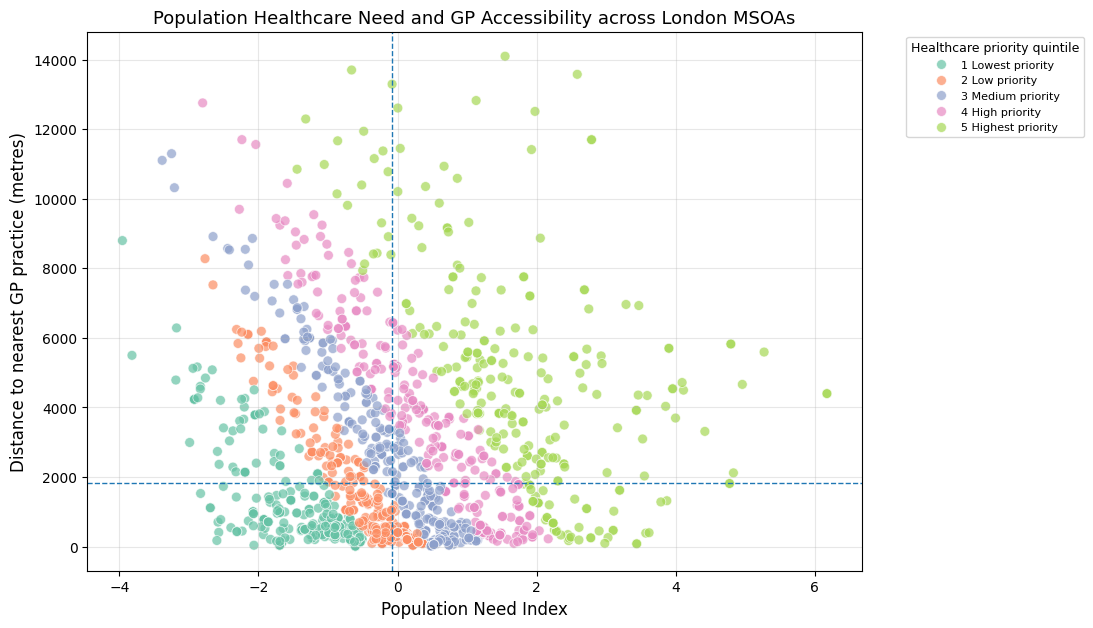

In [30]:
# Final non-spatial visualisation: relationship between population need and GP accessibility

# Create a copy of the final MSOA priority dataset for the non-spatial visualisation
scatter_data = msoa_priority.copy()
# Calculate the median value of the Population Need Index
median_need = scatter_data["population_need_index"].median()
# Calculate the median value of the distance
median_distance = scatter_data["nearest_gp_distance_m"].median()
# Set the overall figure size
plt.figure(figsize=(10, 7))
# Create a scatter plot showing the relationship between population need and GP distance
ax=sns.scatterplot(
    data=scatter_data,
    x="population_need_index",
    y="nearest_gp_distance_m",
    hue="priority_quintile",
    s=50,
    alpha=0.7,
    palette='Set2'
)
# Add a vertical reference line showing the median Population Need Index
ax.axvline(
    median_need,
    linestyle="--",
    linewidth=1
)
# Add a horizontal reference line showing the median distance to the nearest GP practice
ax.axhline(
    median_distance,
    linestyle="--",
    linewidth=1
)
# set the plot title
plt.title('Population Healthcare Need and GP Accessibility across London MSOAs', fontsize=13)
# Add x and y axis labels
plt.xlabel('Population Need Index', fontsize=12)
plt.ylabel('Distance to nearest GP practice (metres)', fontsize=12)
# Add a grid
plt.grid(alpha=0.3)
# Add a legend title
plt.legend(title='Healthcare priority quintile',fontsize=8, title_fontsize=9,bbox_to_anchor=(1.05, 1), loc='upper left')
# Show the plot
plt.show()

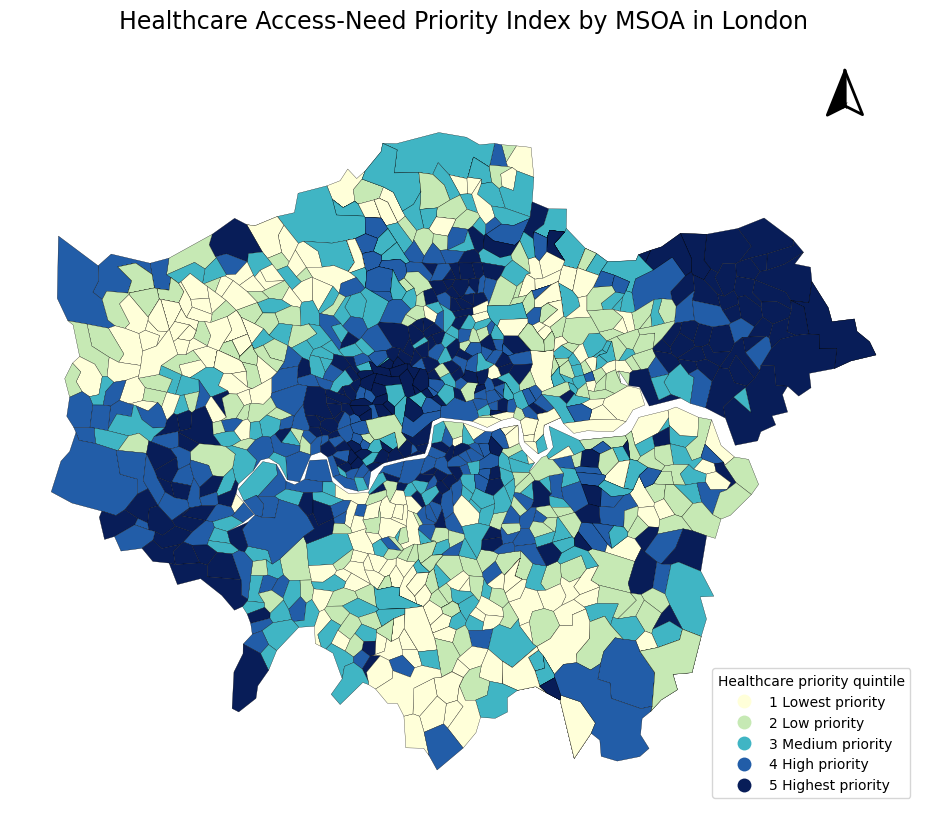

In [51]:
# Create a copy of the final MSOA priority dataset for mapping
map_data = msoa_priority.copy()
# Create a new figure and axis
fig,ax = plt.subplots(figsize=(25, 10))
# Plot the MSOA-level healthcare priority quintiles as a map
map_data .plot(ax=ax,
    column='priority_quintile',
    cmap='YlGnBu',
    legend=True,
    edgecolor='black',
    linewidth=0.2,
    legend_kwds={"title": "Healthcare priority quintile",
                 "loc": "lower right"
                 })
# remove axis
ax.set_axis_off()

# Add a title
ax.set_title("Healthcare Access-Need Priority Index by MSOA in London",
             fontsize=17, pad=5)
# Add a north arrow
add_north_arrow(ax, scale=0.5,xlim_pos=0.92, ylim_pos=0.98)
# Display the map
plt.show()

## References
<p><a href="add_url_here">[1] </a>Footnote citation goes here</p>
<p><a href="https://github.com/FrancescaPontin/GEOG5990">[2] </a>GEOG5990M course materials</p>
<p><a href="https://doi.org/10.1186/s40163-020-00121-w">[3] </a>Halford, E., Dixon, A., Farrell, G., Malleson, N. and Tilley, N., 2020. Crime and coronavirus: Social distancing, lockdown, and the mobility elasticity of crime. Crime science, 9(1), p.11</p>